In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Generate sample data (provided in the problem description)
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)



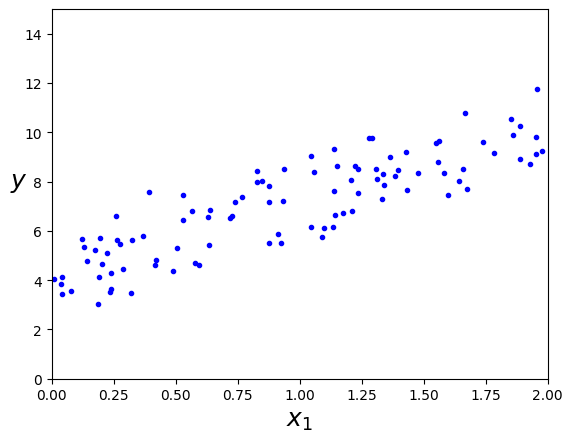

In [ ]:
# prompt: plot above data

# Plot the data
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()


this is the given dataset and we will now try to fit a line through this data with least squares

In [ ]:
# Add x0 = 1 to each instance
X_b = np.c_[np.ones((len(X), 1)), X]  # add x0 = 1 to each instance

# Learning parameters
learning_rate = 0.1
n_iterations = 1000

# Initialize theta randomly
theta = np.random.randn(2,1)

In [ ]:

# Gradient Descent for all points at same time
#for iteration in range(n_iterations):
    #gradients = 2/len(X) * X_b.T.dot(X_b.dot(theta) - y)
    #theta = theta - learning_rate * gradients

In [ ]:
# Gradient Descent without matrix operations
start_time = time.time()
for iteration in range(n_iterations):
    gradients = [0] * len(theta)  # Initialize gradients to zero

    for i in range(len(X)):  # Loop through each data point
        prediction = sum(theta[j] * X_b[i][j] for j in range(len(theta)))  # Compute prediction
        error = prediction - y[i]

        for j in range(len(theta)):  # Update gradient for each parameter
            gradients[j] += (2 / len(X)) * error * X_b[i][j]

    # Update parameters theta
    for j in range(len(theta)):
        theta[j] -= learning_rate * gradients[j]

end_time = time.time()
gd_time = end_time - start_time

Gradient Descent time: 2.8253 seconds
Estimated Coefficients (Gradient Descent): [[4.22215108]
 [2.96846751]]


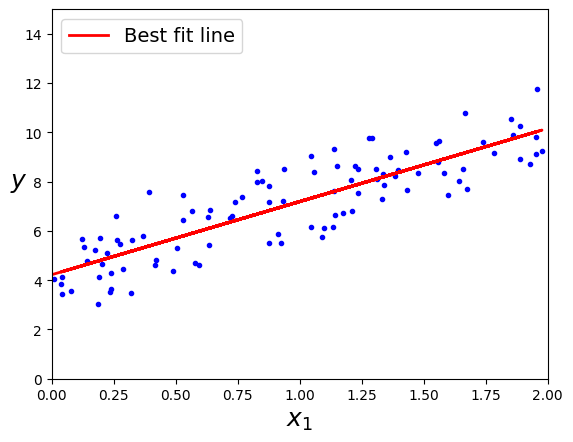

In [ ]:
print(f"Gradient Descent time: {gd_time:.4f} seconds")
print("Estimated Coefficients (Gradient Descent):", theta)

# Predictions using the estimated coefficients
y_predict_gd = X_b.dot(theta)


# Plot the results
plt.plot(X, y, "b.")
plt.plot(X, y_predict_gd, "r-", linewidth=2, label="Best fit line")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.legend(loc="upper left", fontsize=14)
plt.show()

gilbert strang lecture, solving linear regression with projection matrix

Estimated Coefficients (Projection Matrix): [[4.22215108]
 [2.96846751]]


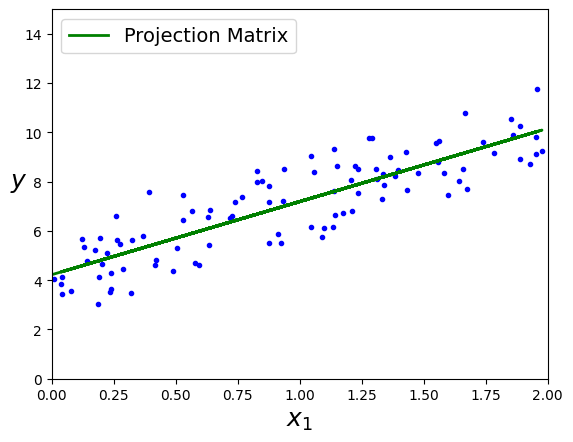

In [ ]:
# prompt: solve linear legression using projection matrix

# Calculate the projection matrix
X_transpose = X_b.T
projection_matrix = np.linalg.inv(X_transpose.dot(X_b)).dot(X_transpose) # The order of multiplication was changed here

# Calculate the theta using the projection matrix
theta_projection = projection_matrix.dot(y)

print("Estimated Coefficients (Projection Matrix):", theta_projection)

# Predictions using the estimated coefficients from the projection matrix
y_predict_projection = X_b.dot(theta_projection)

# Plot the results for the projection matrix method
plt.plot(X, y, "b.")
plt.plot(X, y_predict_projection, "g-", linewidth=2, label="Projection Matrix")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.legend(loc="upper left", fontsize=14)
plt.show()

Stochastic Gradient Descent time: 1.1864 seconds
Estimated Coefficients (Stochastic Gradient Descent): [[3.63850474]
 [2.71706202]]


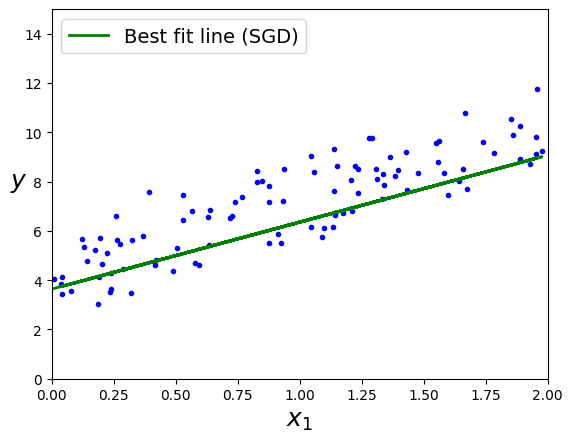

In [ ]:


# Initialize theta randomly
theta = np.random.randn(2,1)

start_time = time.time()
# Stochastic Gradient Descent
m = 100
for iteration in range(n_iterations):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        theta = theta - learning_rate * gradients

end_time = time.time()
sgd_time = end_time - start_time
print(f"Stochastic Gradient Descent time: {sgd_time:.4f} seconds")

print("Estimated Coefficients (Stochastic Gradient Descent):", theta)

# Predictions using the estimated coefficients
y_predict_sgd = X_b.dot(theta)

# Plot the results
plt.plot(X, y, "b.")
plt.plot(X, y_predict_sgd, "g-", linewidth=2, label="Best fit line (SGD)")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.legend(loc="upper left", fontsize=14)
plt.show()

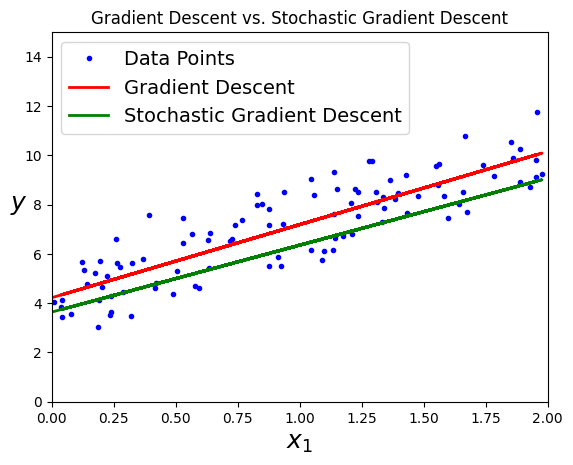

In [ ]:
# Plot both results on the same plot
plt.plot(X, y, "b.", label="Data Points")
plt.plot(X, y_predict_gd, "r-", linewidth=2, label="Gradient Descent")
plt.plot(X, y_predict_sgd, "g-", linewidth=2, label="Stochastic Gradient Descent")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.legend(loc="upper left", fontsize=14)
plt.title("Gradient Descent vs. Stochastic Gradient Descent")
plt.show()

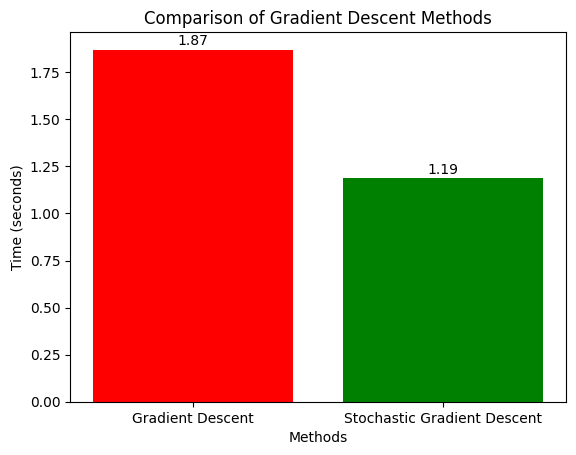

In [ ]:

# Create the bar graph
methods = ['Gradient Descent', 'Stochastic Gradient Descent']
times = [gd_time, sgd_time]

plt.bar(methods, times, color=['red', 'green'])
plt.xlabel("Methods")
plt.ylabel("Time (seconds)")
plt.title("Comparison of Gradient Descent Methods")
# Add time values on top of the bars
for i, time in enumerate(times):
    plt.text(i, time + 0.01, f'{time:.2f}', ha='center', va='bottom', fontsize=10, color='black')


plt.show()

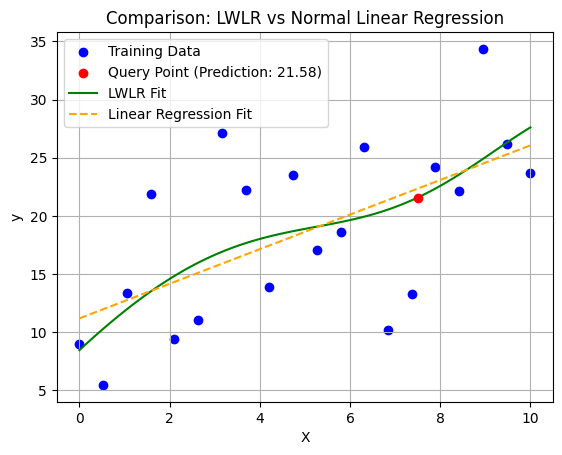

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Define Gaussian kernel function
def gaussian_kernel(xi, xq, tau):
    """Calculate the weight for xi based on its distance to xq."""
    return np.exp(-np.sum((xi - xq) ** 2) / (2 * tau ** 2))

# Define LWLR function
def locally_weighted_linear_regression(X, y, x_query, tau):
    """
    Perform LWLR for a given query point.
    X: Training features (n_samples, n_features)
    y: Training targets (n_samples,)
    x_query: Query point (n_features,)
    tau: Bandwidth parameter
    """
    # Add intercept term to X and x_query
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    x_query = np.hstack([1, x_query])  # Include intercept term for query

    # Compute weights
    weights = np.array([gaussian_kernel(xi, x_query, tau) for xi in X])
    W = np.diag(weights)

    # Compute theta using weighted normal equation
    theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ y)

    # Predict value for the query point
    prediction = x_query @ theta
    return prediction

# Generate sample data with higher variance in y
np.random.seed(42)
X_train = np.linspace(0, 10, 20).reshape(-1, 1)  # Features
y_train = 3 * X_train.squeeze() + 5 + np.random.normal(0, 8, X_train.shape[0])  # Linear relation with high noise


# Query point and bandwidth
x_query = np.array([7.5])  # Query point
tau = 2.0  # Bandwidth

# Apply LWLR to the query point
prediction = locally_weighted_linear_regression(X_train, y_train, x_query, tau)

# Train a normal linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_linear = linear_model.predict(np.linspace(0, 10, 100).reshape(-1, 1))

# Generate LWLR smooth predictions for comparison
X_smooth = np.linspace(0, 10, 100).reshape(-1, 1)
y_smooth = np.array([locally_weighted_linear_regression(X_train, y_train, x, tau) for x in X_smooth])

# Plot the data points
plt.scatter(X_train, y_train, label="Training Data", color="blue")

# Mark the query point
plt.scatter(x_query, prediction, color="red", label=f"Query Point (Prediction: {prediction:.2f})", zorder=5)

# Draw the LWLR fit line
plt.plot(X_smooth, y_smooth, label="LWLR Fit", color="green")

# Draw the normal linear regression line
plt.plot(X_smooth, y_linear, label="Linear Regression Fit", color="orange", linestyle="--")

# Label the plot
plt.title("Comparison: LWLR vs Normal Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


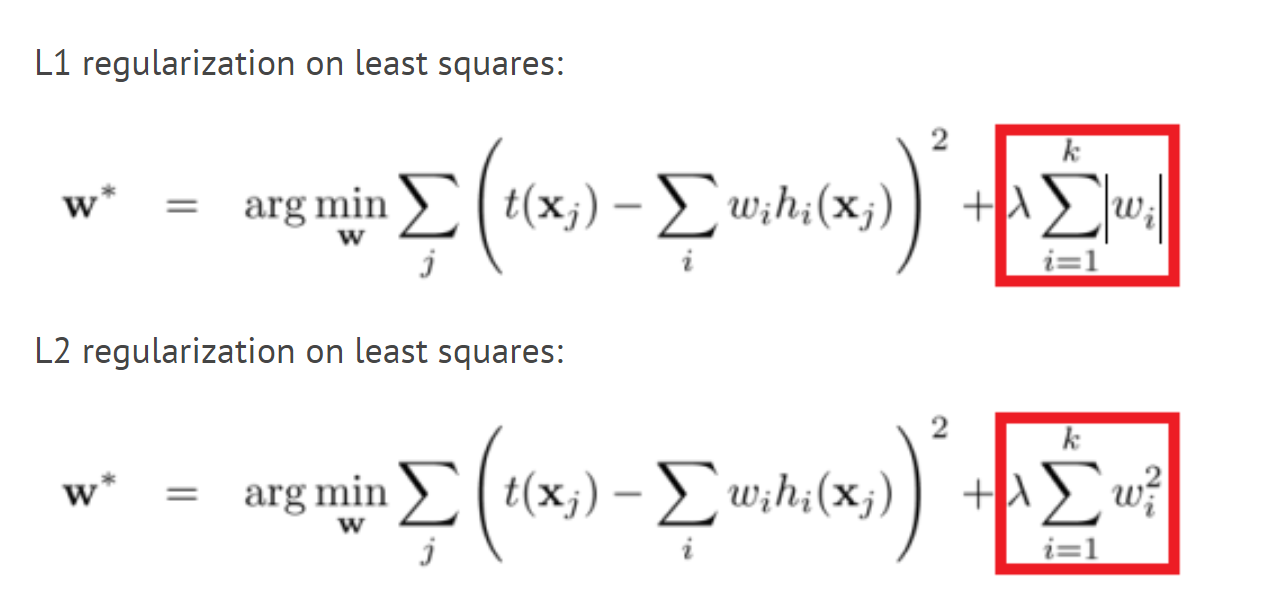

#L1


<ipython-input-28-94bed85cd289>:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gradients[j] += (2 / len(X)) * error * X_b[i][j] + 0.01 * np.sign(theta[j])  # Gradient computation


Estimated Coefficients (Gradient Descent): [3.79952862 2.8866374 ]


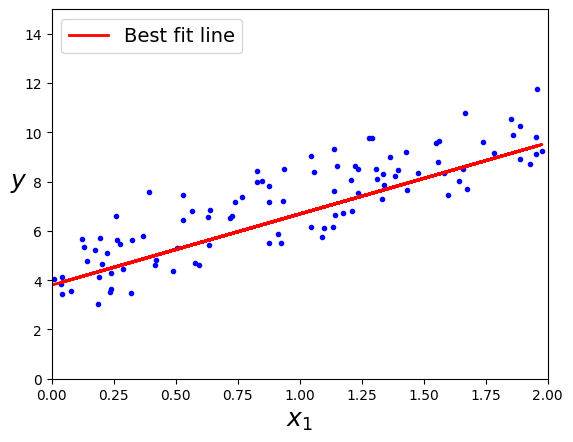

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Add x0 = 1 to each instance
X_b = np.c_[np.ones((len(X), 1)), X]  # Add x0 = 1 to each instance

# Learning parameters
learning_rate = 0.1
n_iterations = 1000

# Initialize theta randomly
theta = np.random.randn(X_b.shape[1])

# Perform Gradient Descent
for iteration in range(n_iterations):
    gradients = np.zeros_like(theta)  # Initialize gradients as zeros

    # Compute gradients manually
    for i in range(len(X)):  # Loop over each data point
        prediction = sum(theta[j] * X_b[i][j] for j in range(len(theta)))  # Prediction
        error = prediction - y[i]

        for j in range(len(theta)):  # Loop over each parameter
            gradients[j] += (2 / len(X)) * error * X_b[i][j] + 0.01 * np.sign(theta[j])  # Gradient computation

    # Update theta parameters
    for j in range(len(theta)):
        theta[j] -= learning_rate * gradients[j]

print("Estimated Coefficients (Gradient Descent):", theta)

# Predictions using the estimated coefficients
y_predict_gd = [sum(theta[j] * X_b[i][j] for j in range(len(theta))) for i in range(len(X))]

# Plot the results
plt.plot(X, y, "b.")
plt.plot(X, y_predict_gd, "r-", linewidth=2, label="Best fit line")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.legend(loc="upper left", fontsize=14)
plt.show()


#L2

<ipython-input-31-2130c7e313b6>:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gradients[j] += (2 / len(X)) * error * X_b[i][j] + 0.001 * (theta[j])* (theta[j]) # Gradient computation


Estimated Coefficients (Gradient Descent): [3.44792946 3.15862517]


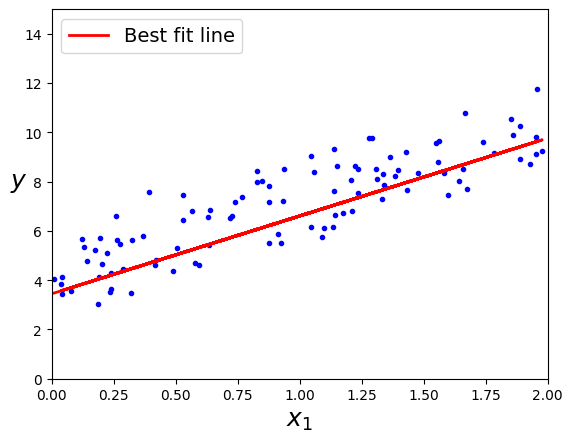

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Add x0 = 1 to each instance
X_b = np.c_[np.ones((len(X), 1)), X]  # Add x0 = 1 to each instance

# Learning parameters
learning_rate = 0.1
n_iterations = 1000

# Initialize theta randomly
theta = np.random.randn(X_b.shape[1])

# Perform Gradient Descent
for iteration in range(n_iterations):
    gradients = np.zeros_like(theta)  # Initialize gradients as zeros

    # Compute gradients manually
    for i in range(len(X)):  # Loop over each data point
        prediction = sum(theta[j] * X_b[i][j] for j in range(len(theta)))  # Prediction
        error = prediction - y[i]

        for j in range(len(theta)):  # Loop over each parameter
            gradients[j] += (2 / len(X)) * error * X_b[i][j] + 2*0.01 * (theta[j]) # Gradient computation

    # Update theta parameters
    for j in range(len(theta)):
        theta[j] -= learning_rate * gradients[j]

print("Estimated Coefficients (Gradient Descent):", theta)

# Predictions using the estimated coefficients
y_predict_gd = [sum(theta[j] * X_b[i][j] for j in range(len(theta))) for i in range(len(X))]

# Plot the results
plt.plot(X, y, "b.")
plt.plot(X, y_predict_gd, "r-", linewidth=2, label="Best fit line")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.legend(loc="upper left", fontsize=14)
plt.show()


In [ ]:
print(X_b)

[[1.         0.77735458]
 [1.         0.54269806]
 [1.         1.65747502]
 [1.         0.71350665]
 [1.         0.56186902]
 [1.         1.08539217]
 [1.         0.28184845]
 [1.         1.60439396]
 [1.         0.14910129]
 [1.         1.97377387]
 [1.         1.54448954]
 [1.         0.39743136]
 [1.         0.01104423]
 [1.         1.63092286]
 [1.         1.41371469]
 [1.         1.45801434]
 [1.         1.54254069]
 [1.         0.1480893 ]
 [1.         0.71693146]
 [1.         0.23173812]
 [1.         1.72620685]
 [1.         1.24659625]
 [1.         0.66179605]
 [1.         0.1271167 ]
 [1.         0.62196464]
 [1.         0.65036664]
 [1.         1.45921236]
 [1.         1.27511494]
 [1.         1.77442549]
 [1.         0.94442985]
 [1.         0.23918849]
 [1.         1.42648957]
 [1.         1.5215701 ]
 [1.         1.1225544 ]
 [1.         1.54193436]
 [1.         0.98759119]
 [1.         1.04546566]
 [1.         0.85508204]
 [1.         0.05083825]
 [1.         0.21578285]


In [ ]:
import numpy as np

# Sample data
a = np.array([[1, 2], [2, 4], [4, 5], [6, 8]])
X, y = a[:, 0], a[:, 1]

# Initialize theta
theta = np.random.randn(1)

# Gradient Descent
for _ in range(100):
    prediction = X * theta
    gradient = -np.sum((y - prediction) * X)
    theta -= 0.01 * gradient

print(f"Final theta: {theta}")


Final theta: [1.36842105]


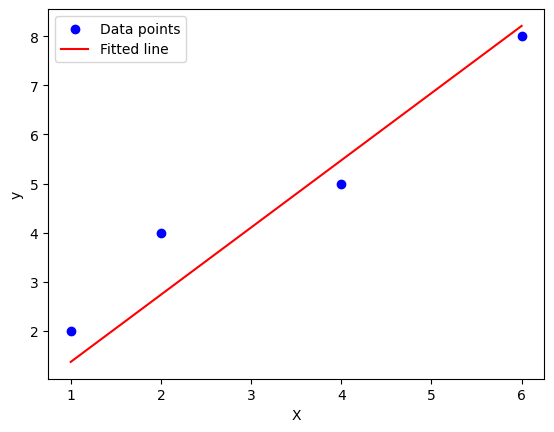

Final theta: [1.36842105]


In [ ]:
# Plot the results
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, X * theta, color='red', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

print(f"Final theta: {theta}")